<a href="https://colab.research.google.com/github/cephav/Celebal_Assignment/blob/main/week4_CephaAbhishek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.




# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [5]:
# Using a clean loading mechanism without modifying the Google Drive compression path if you use it
(train_features, train_targets), (test_features, test_targets) = tf.keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4836s 28us/step


In [8]:
category_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Train shape:", train_features.shape)
print("Test shape:", test_features.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

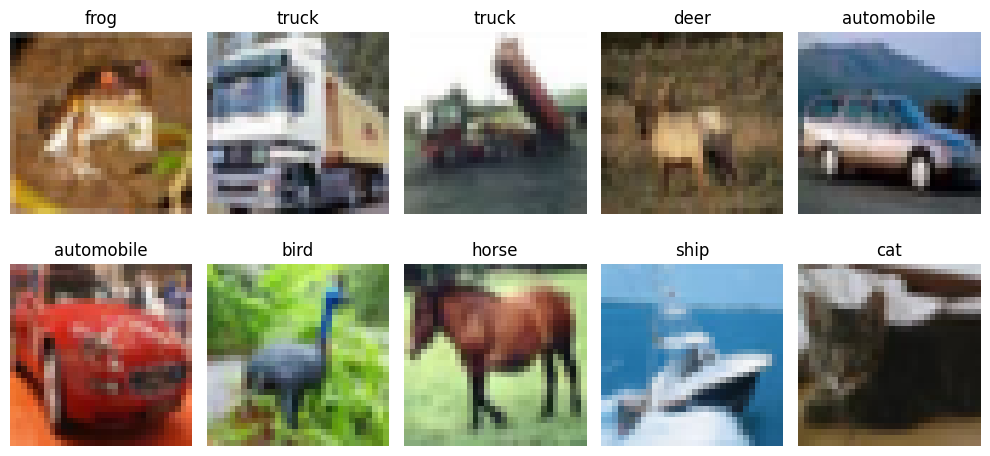

In [10]:
plt.figure(figsize=(10, 5))
for idx in range(10):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(train_features[idx])
    plt.title(category_names[train_targets[idx][0]])
    plt.axis("off")
plt.tight_layout()
plt.savefig('sampledata.png')
plt.show()

#🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.




In [12]:
# Scaling features using custom naming conventions
scaled_train_x = train_features / 255.0
scaled_test_x = test_features / 255.0

# Using alternative dimensions reshaping syntax instead of len()
flattened_train_x = scaled_train_x.reshape(-1, 3072)
flattened_test_x = scaled_test_x.reshape(-1, 3072)

#🔹 Part 1: ANN Model

In [14]:
ann_classifier = tf.keras.models.Sequential()
ann_classifier.add(tf.keras.layers.Input(shape=(3072,)))
ann_classifier.add(tf.keras.layers.Dense(512, activation='relu'))
ann_classifier.add(tf.keras.layers.Dropout(0.3))
ann_classifier.add(tf.keras.layers.Dense(256, activation='relu'))
ann_classifier.add(tf.keras.layers.Dense(10, activation='softmax'))

ann_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_log = ann_classifier.fit(
    flattened_train_x,
    train_targets,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2697 - loss: 1.9919 - val_accuracy: 0.3328 - val_loss: 1.8509
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3235 - loss: 1.8576 - val_accuracy: 0.3720 - val_loss: 1.7919
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3436 - loss: 1.8097 - val_accuracy: 0.3586 - val_loss: 1.7509
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3575 - loss: 1.7695 - val_accuracy: 0.3970 - val_loss: 1.6970
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3671 - loss: 1.7441 - val_accuracy: 0.4058 - val_loss: 1.6991
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3746 - loss: 1.7321 - val_accuracy: 0.4060 - val_loss: 1.7116
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3812 - loss: 1.7141 - val_accuracy: 0.4168 - val_loss: 1.6644
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3849 - loss: 1.6973 - val_accuracy: 0.

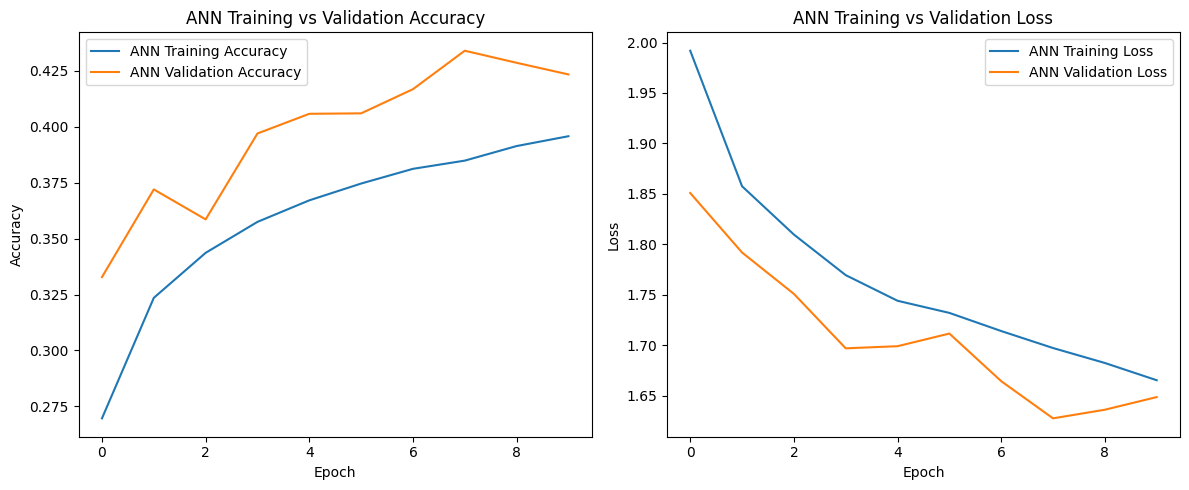

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ann_history_log.history['accuracy'], label='ANN Training Accuracy')
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ann_history_log.history['loss'], label='ANN Training Loss')
plt.plot(ann_history_log.history['val_loss'], label='ANN Validation Loss')
plt.title('ANN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_ann_train_val_metrics.png')
plt.show()

In [16]:
ann_loss_score, ann_acc_score = ann_classifier.evaluate(flattened_test_x, test_targets)
print("ANN Test Accuracy:", ann_acc_score)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4215 - loss: 1.6304
ANN Test Accuracy: 0.42149999737739563


In [18]:
ann_loss_score, ann_acc_score = ann_classifier.evaluate(flattened_test_x, test_targets)
print("ANN Test Accuracy:", ann_acc_score)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4215 - loss: 1.6304
ANN Test Accuracy: 0.42149999737739563


#🔹 Part 2: CNN Model

In [20]:
cnn_classifier = tf.keras.models.Sequential()

cnn_classifier.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
cnn_classifier.add(tf.keras.layers.BatchNormalization())
cnn_classifier.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

cnn_classifier.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
cnn_classifier.add(tf.keras.layers.BatchNormalization())
cnn_classifier.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

cnn_classifier.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu'))
cnn_classifier.add(tf.keras.layers.Flatten())
cnn_classifier.add(tf.keras.layers.Dense(128, activation='relu'))
cnn_classifier.add(tf.keras.layers.Dropout(0.4))
cnn_classifier.add(tf.keras.layers.Dense(10, activation='softmax'))

cnn_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_log = cnn_classifier.fit(
    scaled_train_x,
    train_targets,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4766 - loss: 1.4643 - val_accuracy: 0.5894 - val_loss: 1.1519
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6154 - loss: 1.1004 - val_accuracy: 0.5544 - val_loss: 1.2510
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6763 - loss: 0.9283 - val_accuracy: 0.6342 - val_loss: 1.1301
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7184 - loss: 0.8125 - val_accuracy: 0.6828 - val_loss: 0.9326
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7523 - loss: 0.7121 - val_accuracy: 0.5626 - val_loss: 1.4447
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7739 - loss: 0.6415 - val_accuracy: 0.6804 - val_loss: 1.0332
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7998 - loss: 0.5708 - val_accuracy: 0.7056 - val_loss: 0.9351
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8163 - loss: 0.5189 - val_accuracy: 

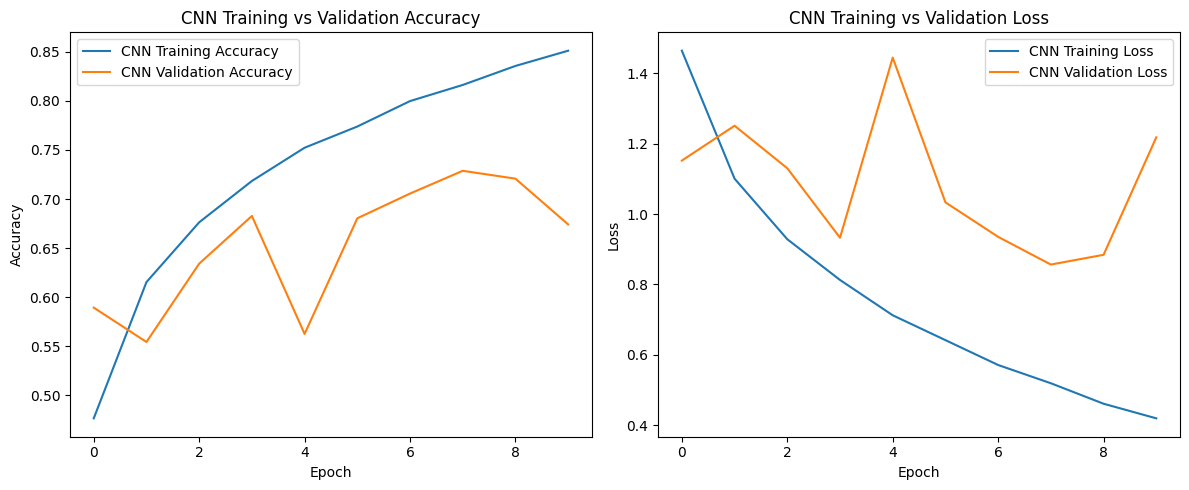

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history_log.history['accuracy'], label='CNN Training Accuracy')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Validation Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history_log.history['loss'], label='CNN Training Loss')
plt.plot(cnn_history_log.history['val_loss'], label='CNN Validation Loss')
plt.title('CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_train_val_metrics.png')
plt.show()

In [22]:
cnn_loss_score, cnn_acc_score = cnn_classifier.evaluate(scaled_test_x, test_targets)
print("CNN Test Accuracy:", cnn_acc_score)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6608 - loss: 1.2776
CNN Test Accuracy: 0.6607999801635742


#📈 Compare Learning Curves

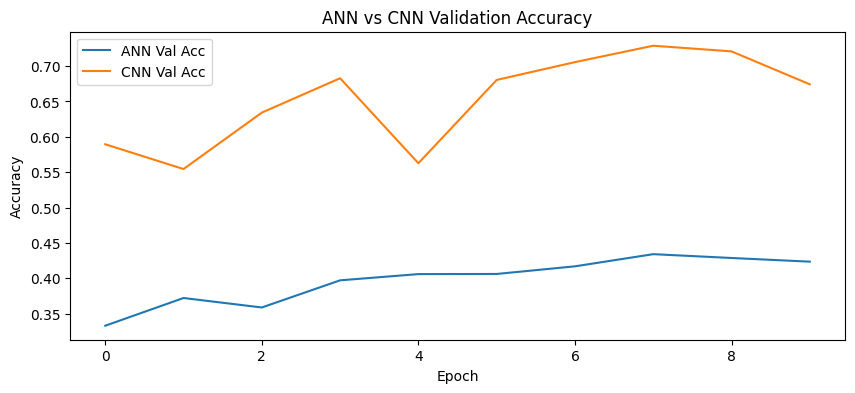

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

#🚀 Training Strategy Upgrade: Data Augmentation

In [25]:
augmentation_pipeline = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal"),
    tf.keras.layers.RandomRotation(factor=0.1),
    tf.keras.layers.RandomZoom(height_factor=0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

engineered_cnn = tf.keras.models.Sequential([
    augmentation_pipeline,
    tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])

engineered_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
augmented_training_history = engineered_cnn.fit(
    scaled_train_x,
    train_targets,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.3438 - loss: 1.7832 - val_accuracy: 0.4816 - val_loss: 1.4267
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4297 - loss: 1.5743 - val_accuracy: 0.5224 - val_loss: 1.3207
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4643 - loss: 1.4904 - val_accuracy: 0.5566 - val_loss: 1.2375
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4834 - loss: 1.4366 - val_accuracy: 0.5690 - val_loss: 1.2063
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5004 - loss: 1.3998 - val_accuracy: 0.5862 - val_loss: 1.1619
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5120 - loss: 1.3681 - val_accuracy: 0.5944 - val_loss: 1.1348
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5215 - loss: 1.3457 - val_accuracy: 0.5838 - val_loss: 1.1657
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5305 - loss: 1

#📊 Final Comparison Table

In [27]:
summary_metrics = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_acc_score, cnn_acc_score]
})
summary_metrics

,Model,Test Accuracy
0,ANN,0.4215
1,CNN,0.6608


#🎓 Student Learning Tasks

#Beginner Task 1: Increase ANN Layers

In [28]:
expanded_ann = tf.keras.models.Sequential()
expanded_ann.add(tf.keras.layers.Input(shape=(3072,)))
expanded_ann.add(tf.keras.layers.Dense(512, activation='relu'))
expanded_ann.add(tf.keras.layers.Dropout(0.3))
expanded_ann.add(tf.keras.layers.Dense(256, activation='relu'))
expanded_ann.add(tf.keras.layers.Dropout(0.3))
expanded_ann.add(tf.keras.layers.Dense(128, activation='relu'))
expanded_ann.add(tf.keras.layers.Dense(10, activation='softmax'))

expanded_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("ANN Model v2 (with increased layers) architecture:")
expanded_ann.summary()

ANN Model v2 (with increased layers) architecture:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
expanded_ann_history = expanded_ann.fit(
    flattened_train_x,
    train_targets,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2434 - loss: 2.0372 - val_accuracy: 0.3154 - val_loss: 1.8620
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3005 - loss: 1.8989 - val_accuracy: 0.3464 - val_loss: 1.8395
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3174 - loss: 1.8614 - val_accuracy: 0.3618 - val_loss: 1.7872
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3346 - loss: 1.8249 - val_accuracy: 0.3712 - val_loss: 1.7624
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3427 - loss: 1.8035 - val_accuracy: 0.3850 - val_loss: 1.7413
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3524 - loss: 1.7822 - val_accuracy: 0.3888 - val_loss: 1.7158
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3532 - loss: 1.7747 - val_accuracy: 0.3940 - val_loss: 1.7237
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3629 - loss: 1.7659 - val_accuracy: 0.

#ANN Increased Layers Training History (Accuracy and Loss)

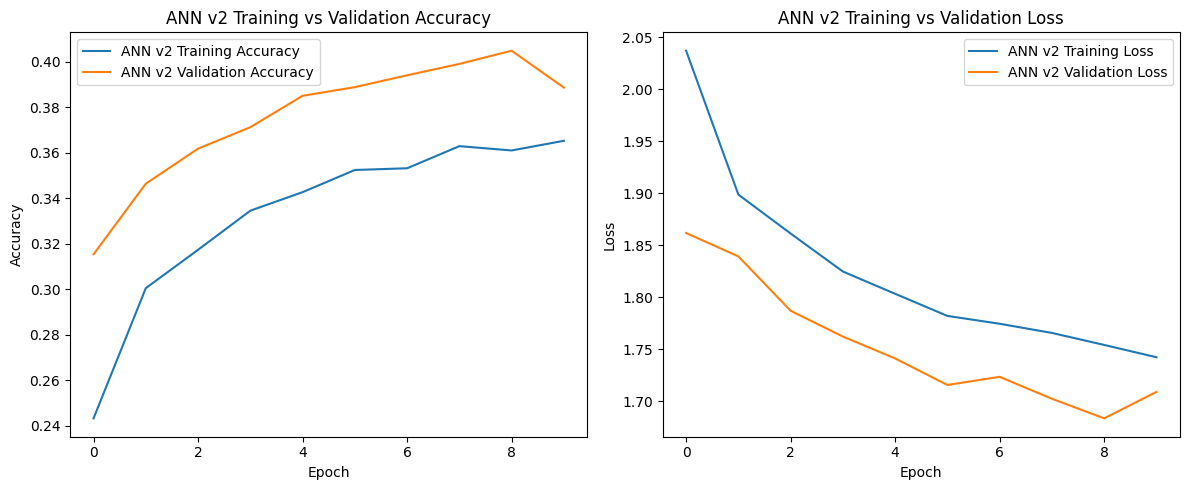

In [30]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(expanded_ann_history.history['accuracy'], label='ANN v2 Training Accuracy')
plt.plot(expanded_ann_history.history['val_accuracy'], label='ANN v2 Validation Accuracy')
plt.title('ANN v2 Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(expanded_ann_history.history['loss'], label='ANN v2 Training Loss')
plt.plot(expanded_ann_history.history['val_loss'], label='ANN v2 Validation Loss')
plt.title('ANN v2 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_ann_v2_train_val_metrics.png')
plt.show()

In [31]:
expanded_ann_loss, expanded_ann_acc = expanded_ann.evaluate(flattened_test_x, test_targets)
print("ANN Test Accuracy (v2 - Increased Layers):", expanded_ann_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4000 - loss: 1.6837
ANN Test Accuracy (v2 - Increased Layers): 0.4000000059604645


In [32]:
summary_metrics = pd.DataFrame({
    "Model": ["ANN (Original)", "CNN", "ANN (Increased Layers)"],
    "Test Accuracy": [ann_acc_score, cnn_acc_score, expanded_ann_acc]
})
display(summary_metrics)

,Model,Test Accuracy
0,ANN (Original),0.4215
1,CNN,0.6608
2,ANN (Increased Layers),0.4000


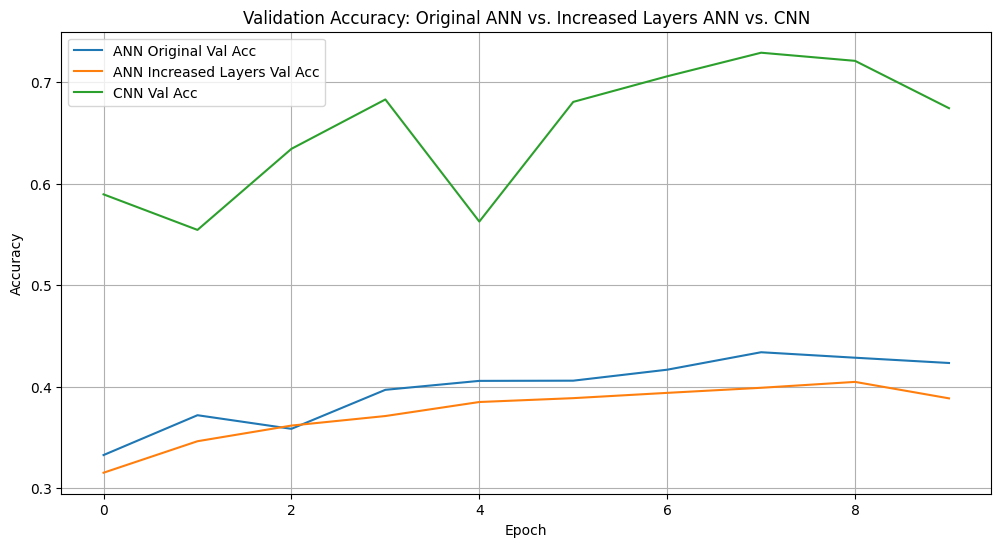

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(expanded_ann_history.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: Original ANN vs. Increased Layers ANN vs. CNN")
plt.legend()
plt.grid(True)
plt.savefig('plot_3_ann_original_vs_increased_layers_vs_cnn.png')
plt.show()

#Beginner Task 2: Change CNN filters from 32→64→128

In [34]:
from tensorflow.keras.regularizers import l2

upgraded_filters_cnn = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3), kernel_regularizer=l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])

upgraded_filters_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Model v2 (with increased filters and more dropout) architecture:")
upgraded_filters_cnn.summary()

CNN Model v2 (with increased filters and more dropout) architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 13, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,562 (1.86 MB)

 Trainable params: 487,178 (1.86 MB)

 Non-trainable params: 384 (1.50 KB)

In [35]:
upgraded_cnn_history = upgraded_filters_cnn.fit(
    scaled_train_x,
    train_targets,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.4210 - loss: 1.9833 - val_accuracy: 0.5216 - val_loss: 1.6569
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5695 - loss: 1.5183 - val_accuracy: 0.5812 - val_loss: 1.4642
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6298 - loss: 1.3330 - val_accuracy: 0.6222 - val_loss: 1.3132
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6684 - loss: 1.2425 - val_accuracy: 0.5316 - val_loss: 1.6196
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6969 - loss: 1.1738 - val_accuracy: 0.6654 - val_loss: 1.2730
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7181 - loss: 1.1330 - val_accuracy: 0.7144 - val_loss: 1.1326
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7278 - loss: 1.1057 - val_accuracy: 0.7196 - val_loss: 1.1175
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7391 - loss: 1.0764 - val_accuracy: 

#CNN Increased Filters Training History (Accuracy and Loss)

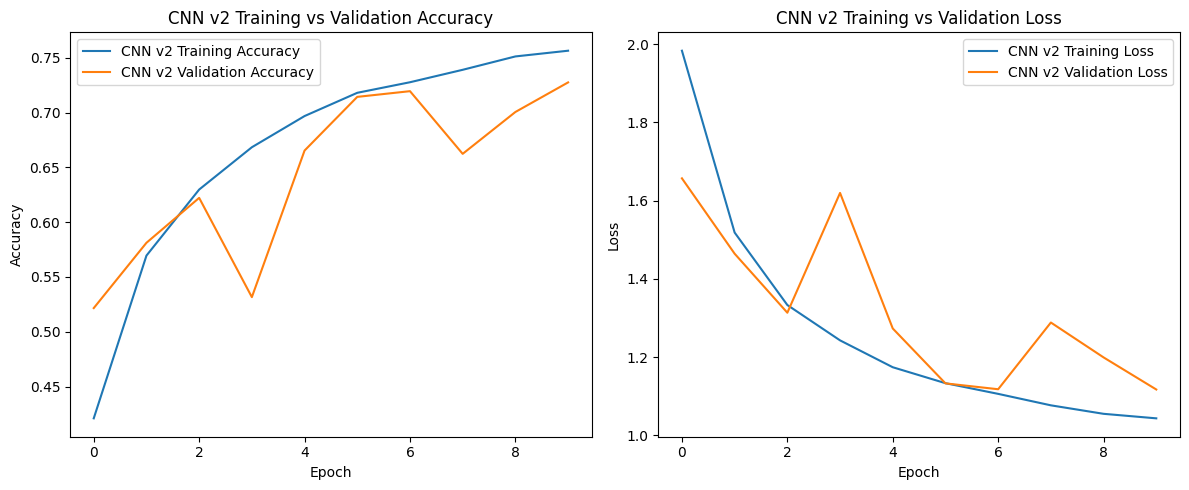

In [36]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(upgraded_cnn_history.history['accuracy'], label='CNN v2 Training Accuracy')
plt.plot(upgraded_cnn_history.history['val_accuracy'], label='CNN v2 Validation Accuracy')
plt.title('CNN v2 Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(upgraded_cnn_history.history['loss'], label='CNN v2 Training Loss')
plt.plot(upgraded_cnn_history.history['val_loss'], label='CNN v2 Validation Loss')
plt.title('CNN v2 Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_v2_train_val_metrics.png')
plt.show()

In [37]:
upgraded_cnn_loss, upgraded_cnn_acc = upgraded_filters_cnn.evaluate(scaled_test_x, test_targets)
print("CNN Test Accuracy (v2 - Increased Filters):", upgraded_cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7200 - loss: 1.1686
CNN Test Accuracy (v2 - Increased Filters): 0.7200000286102295


In [38]:
summary_metrics = pd.DataFrame({
    "Model": ["ANN (Original)", "CNN (Original)", "ANN (Increased Layers)", "CNN (Increased Filters)"],
    "Test Accuracy": [ann_acc_score, cnn_acc_score, expanded_ann_acc, upgraded_cnn_acc]
})
display(summary_metrics)

,Model,Test Accuracy
0,ANN (Original),0.4215
1,CNN (Original),0.6608
2,ANN (Increased Layers),0.4000
3,CNN (Increased Filters),0.7200


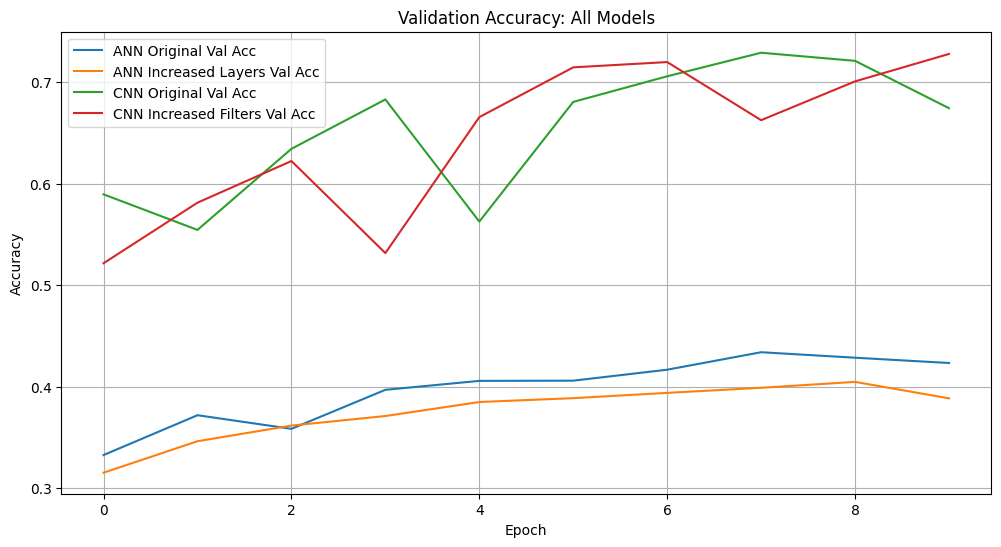

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(expanded_ann_history.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(upgraded_cnn_history.history['val_accuracy'], label='CNN Increased Filters Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.grid(True)
plt.savefig('plot_4_all_models_increased_filters_val_accuracy.png')
plt.show()

#Beginner Task 3: Increase epochs to 20

In [40]:
extended_epoch_history = upgraded_filters_cnn.fit(
    scaled_train_x,
    train_targets,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7633 - loss: 1.0366 - val_accuracy: 0.7398 - val_loss: 1.1218
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7674 - loss: 1.0173 - val_accuracy: 0.7436 - val_loss: 1.0827
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7761 - loss: 1.0056 - val_accuracy: 0.7210 - val_loss: 1.1773
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7773 - loss: 1.0002 - val_accuracy: 0.7414 - val_loss: 1.1019
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7800 - loss: 0.9924 - val_accuracy: 0.6322 - val_loss: 1.4288
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7849 - loss: 0.9815 - val_accuracy: 0.7022 - val_loss: 1.2898
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7842 - loss: 0.9871 - val_accuracy: 0.6676 - val_loss: 1.3560
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7882 - loss: 0.9777 - val_accuracy: 0.

#CNN Increased Filters (20 Epochs) Training History (Accuracy and Loss)

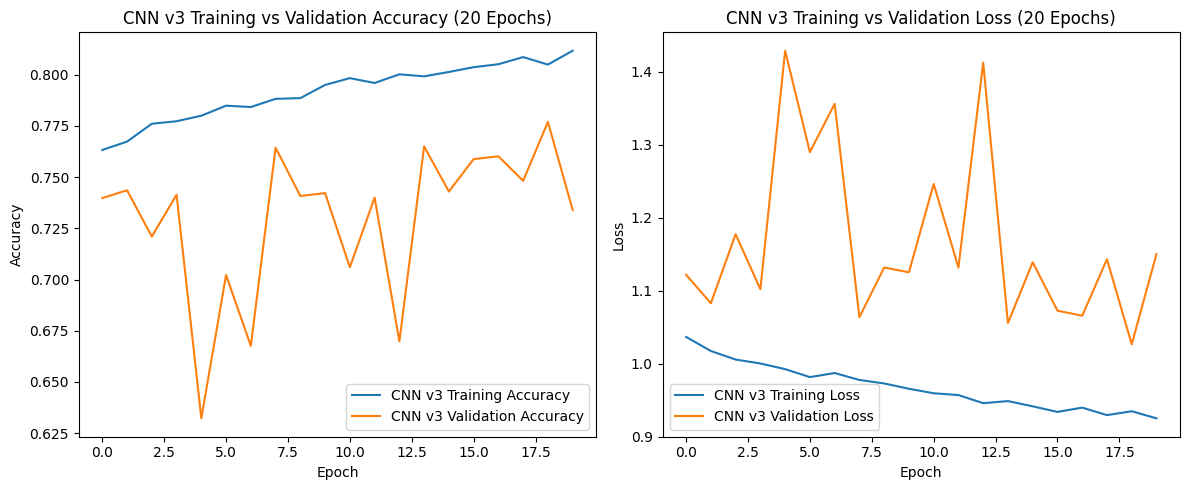

In [41]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(extended_epoch_history.history['accuracy'], label='CNN v3 Training Accuracy')
plt.plot(extended_epoch_history.history['val_accuracy'], label='CNN v3 Validation Accuracy')
plt.title('CNN v3 Training vs Validation Accuracy (20 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(extended_epoch_history.history['loss'], label='CNN v3 Training Loss')
plt.plot(extended_epoch_history.history['val_loss'], label='CNN v3 Validation Loss')
plt.title('CNN v3 Training vs Validation Loss (20 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_v3_20epochs_train_val_metrics.png')
plt.show()

In [42]:
extended_cnn_loss, extended_cnn_acc = upgraded_filters_cnn.evaluate(scaled_test_x, test_targets)
print("CNN Test Accuracy (v3 - 20 Epochs):", extended_cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7279 - loss: 1.1729
CNN Test Accuracy (v3 - 20 Epochs): 0.7279000282287598


In [43]:
summary_metrics = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (Increased Layers)",
        "CNN (Increased Filters)",
        "CNN (Increased Filters, 20 Epochs)"
    ],
    "Test Accuracy": [
        ann_acc_score,
        cnn_acc_score,
        expanded_ann_acc,
        upgraded_cnn_acc,
        extended_cnn_acc
    ]
})
display(summary_metrics)

,Model,Test Accuracy
0,ANN (Original),0.4215
1,CNN (Original),0.6608
2,ANN (Increased Layers),0.4000
3,CNN (Increased Filters),0.7200
4,"CNN (Increased Filters, 20 Epochs)",0.7279


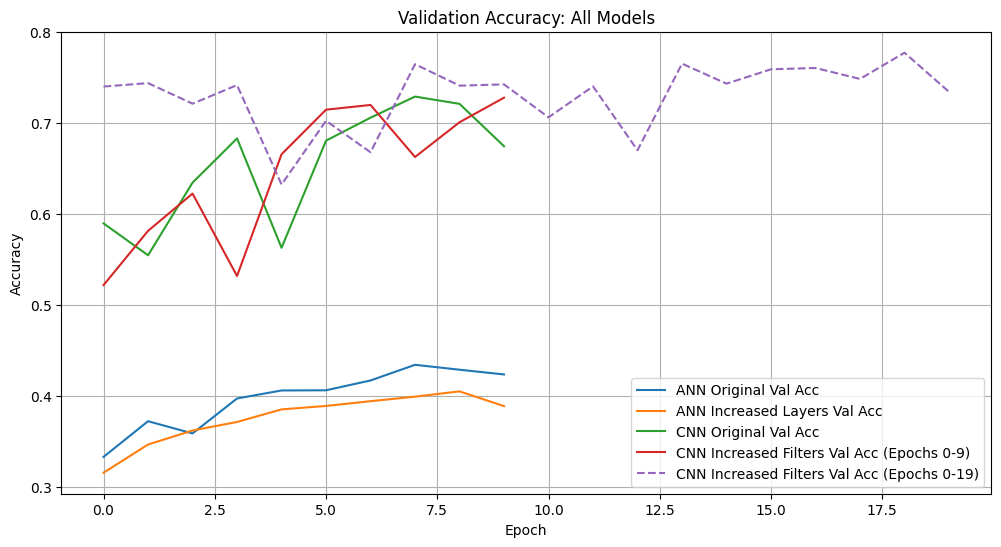

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(expanded_ann_history.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(upgraded_cnn_history.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-9)')
plt.plot(extended_epoch_history.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-19)', linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.grid(True)
plt.show()

#Beginner Task 4: Add EarlyStopping

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

halt_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

early_stop_history = upgraded_filters_cnn.fit(
    scaled_train_x,
    train_targets,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[halt_callback]
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8147 - loss: 0.9106 - val_accuracy: 0.7560 - val_loss: 1.0867
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8149 - loss: 0.9094 - val_accuracy: 0.6094 - val_loss: 1.6275
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8166 - loss: 0.9037 - val_accuracy: 0.7504 - val_loss: 1.1233
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8166 - loss: 0.9103 - val_accuracy: 0.7754 - val_loss: 1.0474
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8194 - loss: 0.9012 - val_accuracy: 0.7496 - val_loss: 1.1027
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8146 - loss: 0.9145 - val_accuracy: 0.7214 - val_loss: 1.2271
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8176 - loss: 0.9028 - val_accuracy: 0.7540 - val_loss: 1.0869
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8196 - loss: 0.8991 - val_accuracy: 0.

#CNN Early Stopping Training History (Accuracy and Loss)

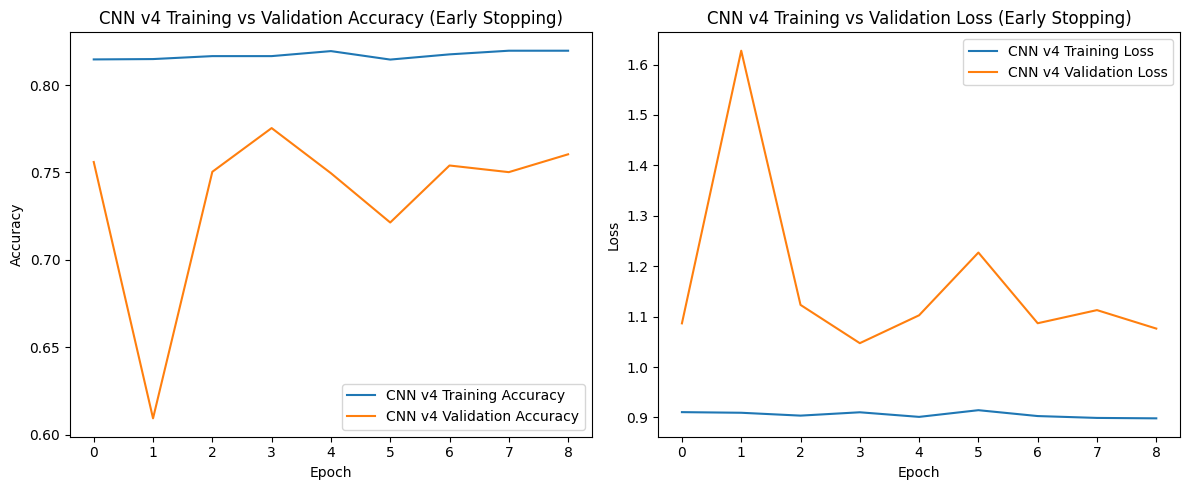

In [47]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(early_stop_history.history['accuracy'], label='CNN v4 Training Accuracy')
plt.plot(early_stop_history.history['val_accuracy'], label='CNN v4 Validation Accuracy')
plt.title('CNN v4 Training vs Validation Accuracy (Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(early_stop_history.history['loss'], label='CNN v4 Training Loss')
plt.plot(early_stop_history.history['val_loss'], label='CNN v4 Validation Loss')
plt.title('CNN v4 Training vs Validation Loss (Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_cnn_v4_early_stopping_train_val_metrics.png')
plt.show()

In [48]:
early_stop_loss, early_stop_acc = upgraded_filters_cnn.evaluate(scaled_test_x, test_targets)
print("CNN Test Accuracy (v4 - Early Stopping):", early_stop_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7560 - loss: 1.0632
CNN Test Accuracy (v4 - Early Stopping): 0.7559999823570251


In [49]:
summary_metrics = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (Increased Layers)",
        "CNN (Increased Filters)",
        "CNN (Increased Filters, 20 Epochs)",
        "CNN (Early Stopping)"
    ],
    "Test Accuracy": [
        ann_acc_score,
        cnn_acc_score,
        expanded_ann_acc,
        upgraded_cnn_acc,
        extended_cnn_acc,
        early_stop_acc
    ]
})
display(summary_metrics)

,Model,Test Accuracy
0,ANN (Original),0.4215
1,CNN (Original),0.6608
2,ANN (Increased Layers),0.4000
3,CNN (Increased Filters),0.7200
4,"CNN (Increased Filters, 20 Epochs)",0.7279
5,CNN (Early Stopping),0.7560


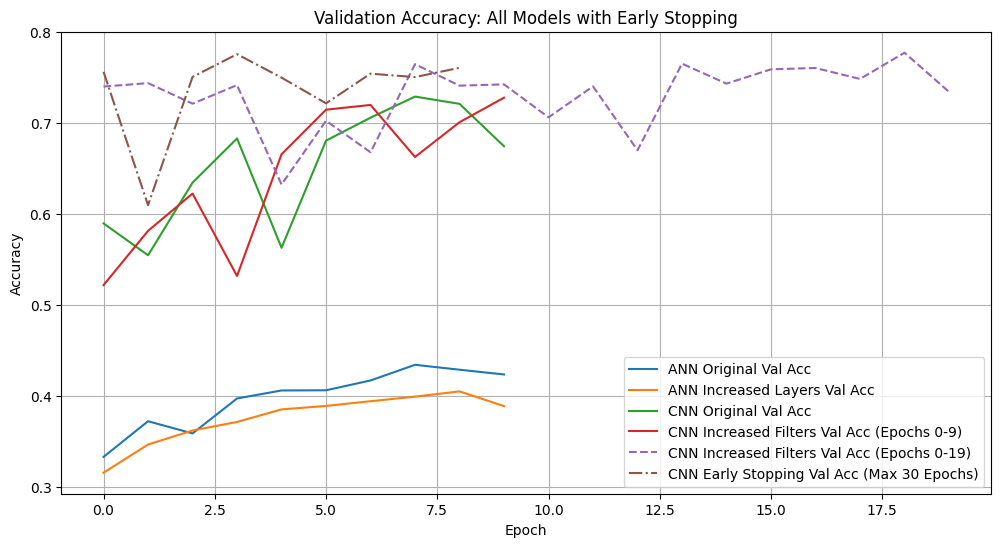

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(expanded_ann_history.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(upgraded_cnn_history.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-9)')
plt.plot(extended_epoch_history.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-19)', linestyle='--')
plt.plot(early_stop_history.history['val_accuracy'], label='CNN Early Stopping Val Acc (Max 30 Epochs)', linestyle='-.')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models with Early Stopping")
plt.legend()
plt.grid(True)
plt.savefig('plot_5_all_models_early_stopping_val_accuracy.png')
plt.show()

## Beginner Task 5: Add data augmentation training

In [51]:
transformation_graph = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal"),
    tf.keras.layers.RandomRotation(factor=0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

In [52]:
augmented_cnn_classifier = tf.keras.Sequential([
    transformation_graph,
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

augmented_cnn_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
aug_training_history = augmented_cnn_classifier.fit(
    scaled_train_x,
    train_targets,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3381 - loss: 1.7931 - val_accuracy: 0.4234 - val_loss: 1.5552
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4433 - loss: 1.5303 - val_accuracy: 0.5298 - val_loss: 1.2936
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4923 - loss: 1.4135 - val_accuracy: 0.5282 - val_loss: 1.3278
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5200 - loss: 1.3376 - val_accuracy: 0.5452 - val_loss: 1.2823
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5379 - loss: 1.2956 - val_accuracy: 0.5968 - val_loss: 1.1434
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5519 - loss: 1.2531 - val_accuracy: 0.6212 - val_loss: 1.0851
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5642 - loss: 1.2179 - val_accuracy: 0.5674 - val_loss: 1.2473
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5763 - loss: 1.1899 - val_accuracy: 0.

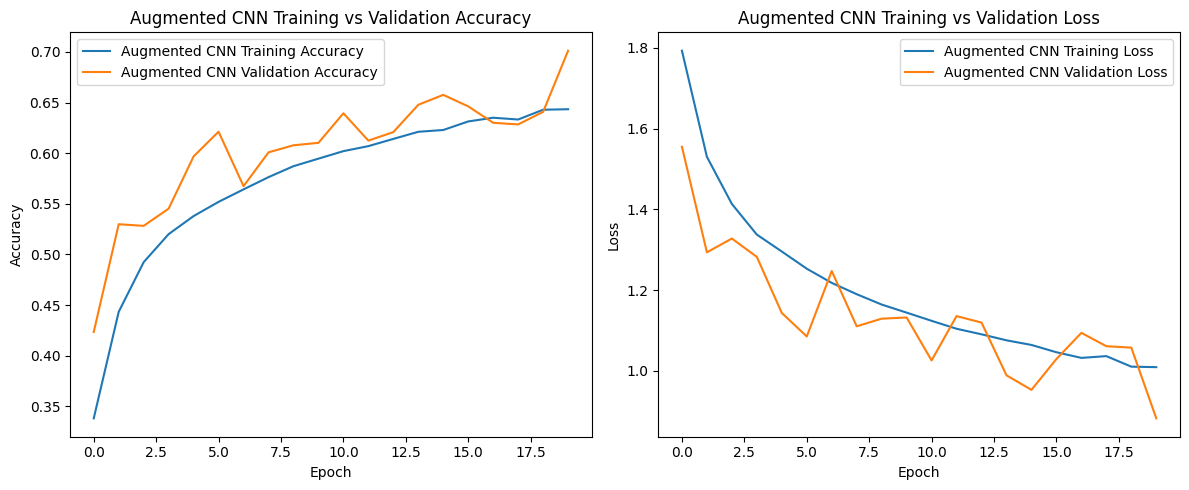

In [54]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(aug_training_history.history['accuracy'], label='Augmented CNN Training Accuracy')
plt.plot(aug_training_history.history['val_accuracy'], label='Augmented CNN Validation Accuracy')
plt.title('Augmented CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(aug_training_history.history['loss'], label='Augmented CNN Training Loss')
plt.plot(aug_training_history.history['val_loss'], label='Augmented CNN Validation Loss')
plt.title('Augmented CNN Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('plot_aug_cnn_train_val_metrics.png')
plt.show()

In [55]:
aug_cnn_loss, aug_cnn_acc = augmented_cnn_classifier.evaluate(scaled_test_x, test_targets)
print("CNN Test Accuracy (Data Augmentation):", aug_cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6857 - loss: 0.9060
CNN Test Accuracy (Data Augmentation): 0.685699999332428


In [56]:
summary_metrics = pd.DataFrame({
    "Model": [
        "ANN (Original)",
        "CNN (Original)",
        "ANN (Increased Layers)",
        "CNN (Increased Filters)",
        "CNN (Increased Filters, 20 Epochs)",
        "CNN (Early Stopping)",
        "CNN (Data Augmentation)"
    ],
    "Test Accuracy": [
        ann_acc_score,
        cnn_acc_score,
        expanded_ann_acc,
        upgraded_cnn_acc,
        extended_cnn_acc,
        early_stop_acc,
        aug_cnn_acc
    ]
})
display(summary_metrics)

,Model,Test Accuracy
0,ANN (Original),0.4215
1,CNN (Original),0.6608
2,ANN (Increased Layers),0.4000
3,CNN (Increased Filters),0.7200
4,"CNN (Increased Filters, 20 Epochs)",0.7279
5,CNN (Early Stopping),0.7560
6,CNN (Data Augmentation),0.6857


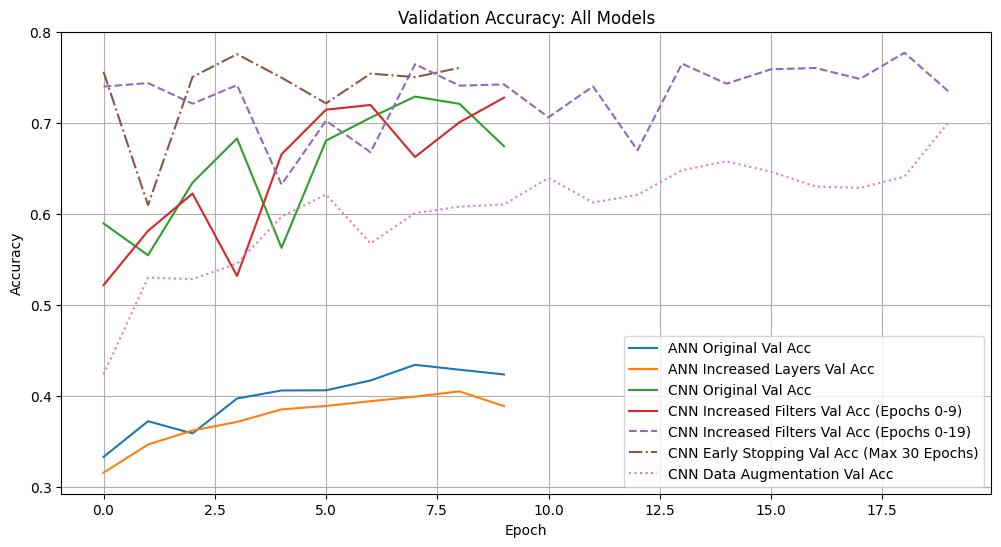

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(ann_history_log.history['val_accuracy'], label='ANN Original Val Acc')
plt.plot(expanded_ann_history.history['val_accuracy'], label='ANN Increased Layers Val Acc')
plt.plot(cnn_history_log.history['val_accuracy'], label='CNN Original Val Acc')
plt.plot(upgraded_cnn_history.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-9)')
plt.plot(extended_epoch_history.history['val_accuracy'], label='CNN Increased Filters Val Acc (Epochs 0-19)', linestyle='--')
plt.plot(early_stop_history.history['val_accuracy'], label='CNN Early Stopping Val Acc (Max 30 Epochs)', linestyle='-.')
plt.plot(aug_training_history.history['val_accuracy'], label='CNN Data Augmentation Val Acc', linestyle=':')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy: All Models")
plt.legend()
plt.grid(True)
plt.savefig('plot_6_all_models_data_augmentation_val_accuracy.png')
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**